# Simple Single Lens (with ARC) simulation with MeepSAT

`NOTE`: First, make sure to connect to the correctly installed version of MeepSAT's jupyter kernel 

In this tutorial, we will simulate a 2D Gaussian beam propagating through a plano-convex lens with anti-reflective (AR) coatings. By the end of this tutorial, you will understand how to:

- Configure simulation parameters in JSON format
- Defining a monochromatic source
- Define simple optical components like lenses and apertures
- Visualize and analyze the electromagnetic field evolution over time.

In [1]:
# Importing various Python libraries and MeepSAT modules
import sys
import os
import site
from pathlib import Path
import meep as mp
import numpy as np
import h5py
import matplotlib.pyplot as plt
import time
import json

# Importing the MEEPSAT librarires
import meepsat.simulator as sim
import meepsat.meep_geometry as comp_meep
import meepsat.permittivity_components as comp_eps
import meepsat.stepfunctions as stepfunctions
import meepsat.json_to_script as json_to_script
import meepsat.field_analysis as mpsat_analysis
import meepsat.helpers as mpsat_helpers

# JSON file path representing mainly the different optical components parameters
json_file_path = 'auxilary_data/simple_single_lens_ARC/simple_single_lens_ARC.json'
data = mpsat_helpers.read_json(json_file_path)

# Savepath: For storing the output generated during the simulation
savepath = 'auxilary_data/simple_single_lens_ARC/output_files'
os.makedirs(savepath, exist_ok=True)

Using MPI version 4.1, 1 processes


Initialising the MeepSAT simulation object from the parameters stored in the JSON file

In [2]:
# Initialising MEEPSAT Simulation
cell_X, cell_Y, cell_Z = data["simulation"]['primary_params']['cell_size']['x'], data["simulation"]['primary_params']['cell_size']['y'], data["simulation"]['primary_params']['cell_size']['z'] # Cell Size without considering the PML thickness and its factor


# Initialize the simulation with the different parameters
mpsat_sim = sim.sim_init(sim_name= str(data["simulation"]["name"]),
                        cell_size= [cell_X, cell_Y, cell_Z], # [sx, sy, sz] in mm
                        smallest_freq= data["simulation"]['primary_params']['smallest_freq'], 
                        resolution= data["simulation"]['primary_params']['resolution'],
                        boundary_layer_type= data['boundary_layers']['boundary']['type'],
                        boundary_layer_size= data['boundary_layers']['boundary']['size'],
                        factor_dpml= data['boundary_layers']['boundary']['factor_dpml'])


Before creating the components, its very important to check if the mentioned resulution and PML boundary layer thickness is enough for our simulation OR not. In Meep FDTD, its recommended to have atleast 8-10 pixels for the smallest wavelength OR length scale present in your system. 

You can check the resolution and verify using `sim.check_resolution_and_pml`

In [3]:
# Checking resolution and PML thickness 
# This function will automatically check all the length scales and wavelength scales
data, mpsat_sim = sim.check_resolution_and_pml(
    data=data, 
    mpsat_sim=mpsat_sim,
    smallest_freq=data["simulation"]['primary_params']['smallest_freq'],
    highest_n=data["lenses"]["lens1"]["n_refr"]
)

# Print the simulation parameters
print("\nMEEPSAT SIMULATION PARAMETERS:")
mpsat_sim.print_simulation_parameters()


Highest refractive index provided:  1.525
Given PML thickness:  2
Given resolution:  3
Assuming the wavelength of the Source to be the largest wavelength present in the system and doing a sanity check on the PML thickness.
Smallest frequency provided:  0.25
Highest refractive index provided:  1.525
Highest refractive index provided:  1.525
Resolution criteria doesn't meet the criteria for the smallest frequency. Increasing the resolution to meet the criteria.
Wavelength Meep:  2.5
Wavelength Meep inside medium:  1.639344262295082
Assuming the wavelength of the Source to be the largest wavelength present in the system and doing a sanity check on the PML thickness.
Smallest frequency provided:  0.25
Resolution criteria doesn't meet the criteria for the ARC layers. Increasing the resolution to meet the criteria.
Resolution criteria doesn't meet the criteria for the ARC layers. Increasing the resolution to meet the criteria.
All length scales of lenses in the simulation:  [0.51, 0.51]
All 

Now let's add a Monochromatic Source 
- You can either follow the Source documentation mentioned in the ReadTheDocs documentation page

    OR

- Just use MeepSAT's built-in function to generate the source from the JSON file

In [4]:
source_list = []
exec(json_to_script.source_script(data))

Angle of the source:3.141592653589793 rad = 180 degrees
Additional arguments for the ContinuousSource:  {'start_time': 0, 'end_time': 1e+20}
Additional arguments for GaussianBeamSource:  {'beam_x0': Vector3<0.0, 0.0, 0.0>, 'beam_E0': Vector3<0.0, 0.0, 1.0>}
Gaussian beam source assembled!


Adding PML boundaries using MEEP

In [5]:
x_left_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.X, side=mp.Low)
x_right_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.X, side=mp.High)
y_down_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.Y, side=mp.Low)
y_up_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.Y, side=mp.High)

custom_boundary_layers = [x_left_boundary, x_right_boundary, y_down_boundary, y_up_boundary]

Now as we need to add a lot of complex structures (lenses, absorbers etc), we will define a empty epsilon map for this purpose. Its basically a 2D spatial discretization array of the simulation domain and the idea is to draw structure on this 2D array

In [6]:
size_x, size_y, size_z = mpsat_sim.cell_size[0], mpsat_sim.cell_size[1], mpsat_sim.cell_size[2]
res = int(mpsat_sim.resolution)  # Ensure resolution is an integer
# Create the epsilon map: total size of the simulation cell in all the axis multiplied by the resolution + 1
epsilon_map = np.ones((int((size_x)*res+1), 
                       int((size_y)*res+1)), dtype = 'float32')

Now as we did for the Source, we will use MeepSAT built in function for defining lenses and aperture

In [7]:
# Adding lens (if given)
exec(json_to_script.add_lens(data))

# Adding aperture (if given)
exec(json_to_script.add_aperture(data))

Saving epsilon map to HDF5 file...
[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]] added to the list of components created using the epsilon functions!
HDF5 file written to /home/ashesh/PhD_work/MeepSAT/output_files/single_lens_testing_ARC_epsilon_map.h5
Aperture stop created with orientation: vertical
type material:  Medium()
Aperture stop created (vertical): Up size=Vector3<1.0, 3.0, 0.0>, Down size=Vector3<1.0, 3.0, 0.0>
Centers: Up=Vector3<20.5, 26.5, 0.0>, Down=Vector3<20.5, -26.5, 0.0>
<meep.geom.Block object at 0x75bc3cc69160> added to the list of components created using the MEEP functions!
<meep.geom.Block object at 0x75bc3c7d8f50> added to the list of components created using the MEEP functions!


Since this system is system at x=0 plane, we will use MEEP's Mirror symmetry

In [8]:
symmetries = [mp.Mirror(mp.Y, phase=+1)] 

Now defining the Meep Simulation Object

In [9]:
simulation = mp.Simulation(
    cell_size=mpsat_sim.cell,
    sources=source_list,
    resolution=mpsat_sim.resolution,
    boundary_layers=custom_boundary_layers,
    geometry=mpsat_sim.meep_geometry,
    epsilon_input_file = data["output"]["savepath"]["path"] + data["output"]["epsilon_h5_file"]["filename"] +"_epsilon_map" + ".h5",
    symmetries = symmetries,
    force_complex_fields= True)

simulation.use_output_directory(savepath)

'auxilary_data/simple_single_lens_ARC/output_files'

Let's run the simulation briefly to store the epsilon map and visualise the permittivity map

-----------
Initializing structure...
read in 2431x841x1 epsilon-input-file "../output_files/single_lens_testing_ARC_epsilon_map.h5"
Halving computational cell along direction y
time for choose_chunkdivision = 0.00279522 s
read in 2431x841x1 epsilon-input-file "../output_files/single_lens_testing_ARC_epsilon_map.h5"
Working in 2D dimensions.
Computational cell is 162 x 56 x 0 with resolution 15
     block, center = (20.5,26.5,0)
          size (1,3,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     block, center = (20.5,-26.5,0)
          size (1,3,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
time for set_epsilon = 2.00871 s
-----------
Meep: using complex fields.
Meep: using output directory 'auxilary_data/simple_single_lens_ARC/output_files'


FloatProgress(value=0.0, description='0% done ', max=0.0)

run 0 finished at t = 0.0 (0 timesteps)


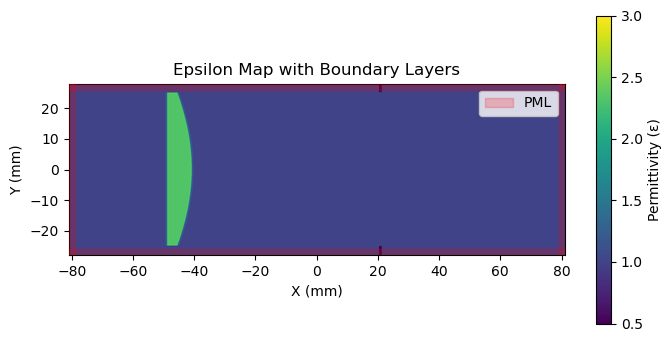

Epsilon plot saved to: auxilary_data/simple_single_lens_ARC/output_files/geometry_plot.png
Epsilon data saved to: auxilary_data/simple_single_lens_ARC/output_files/geometry_plot.h5


In [10]:
sim.plot_and_save_epsilon(
    simulation=simulation,
    savepath=savepath,
    filename_prefix="geometry_plot",
    epsilon_data_name="epsilon",
    size_x=size_x,
    size_y=size_y,
    vmin=0.5,
    vmax=3,
    cmap='viridis',
    figsize=(8, 4),
    dpi=300,
    show_plot= True
)

Now let's set the different run time parameters:
- Animation

    `stepfunctions.set_animation_params(...)`
    - Configures how the simulation will be visualized as an animation
        - `image_every`: Frequency of field snapshots (e.g., every N timesteps)
        - `Nfps`: Frames per second for the output video
        - `anim_file_name`: Output path and filename for the MP4 movie

- Field Parameters

    `stepfunctions.set_field_params(...)`
    - Defines spatial and storage parameters for electromagnetic field data
        - `size_x`, `size_y`: Physical dimensions of the simulation domain
        - `savepath`: Directory where field data will be stored
        - `downsampling_factor_x/y`: Reduces data resolution for storage (e.g., keep every Nth point)

- Runtime Parameters

    `runtime_params = sim.calculate_runtime_parameters(...)`
    - Computes temporal simulation parameters for field extraction based on the source frequency
        - `source_freq`: Operating frequency (extracted from JSON with a typo "frequecy")
        - `total_time`: Total simulation duration
        - `animation_timestep`: Time interval between field captures
        - `points_per_period`: Temporal resolution (10 points per wavelength period)
        - `extraction_offset`: Buffer time before field extraction begins

In [11]:
# Set the stepfunctions parameters
# Animation Parameters
stepfunctions.set_animation_params(anim_params= {'image_every': data["output"]["animation_options"]["image_every"], 
                                              'Nfps': data["output"]["animation_options"]["Nfps"], 
                                              'anim_file_name': savepath + "/"+ data["output"]["animation_options"]["movie_name"] + ".mp4"})
# Field Parameters
stepfunctions.set_field_params(field_params= {'size_x': size_x,
                                              'size_y': size_y,
                                              'savepath': savepath,
                                              'downsampling_factor_x': data["output"]["animation_options"]["downsample_x"],
                                              'downsampling_factor_y': data["output"]["animation_options"]["downsample_y"]})

# Runtime parameters
runtime_params = sim.calculate_runtime_parameters(
    source_freq=float(data["sources"]["source1"]["frequecy"]),
    total_time= 400,
    animation_timestep = data["output"]["animation_options"]["image_every"],
    points_per_period=10,
    extraction_offset=10
)

Field extraction parameters set:
  size_x: 162
  size_y: 56
  savepath: auxilary_data/simple_single_lens_ARC/output_files
  downsampling_factor_x: 1
  downsampling_factor_y: 1
Runtime parameters calculated:
  Period: 2.5000 MEEP time units
  Time step (dt): 0.2500 MEEP time units
  Extraction start time (t0): 390 MEEP time units
  Points per period: 10
  Animation timestep: 25 MEEP time units


Now we are all set to run the simulation!!

In [12]:
simulation.run(mp.at_every(runtime_params["animation_timestep"], stepfunctions.Ez2_dB),
               mp.after_time(runtime_params["t0"], mp.at_every(runtime_params["dt"], stepfunctions.accumulate_efield_and_hfield)),
               mp.at_end(stepfunctions.save_animation),
               mp.at_end(stepfunctions.save_accumulated_fields),
               mp.at_end(stepfunctions.extract_xyzw),
               until = runtime_params["total_time"])

print("Simulation completed.")                                                 

# #~ ---------------------------------------------

# Save the final edited JSON data
with open(data["output"]["savepath"]["path"] + data["simulation"]["name"] + "_simulation_data.json", "w") as f:
    json.dump(data, f, indent=2)
print(f"Simulation parameters saved to: {data['output']['savepath']['path']}{data['simulation']['name']}_simulation_data.json")

FloatProgress(value=0.0, description='0% done ', max=400.0)

Meep progress: 6.7/400.0 = 1.7% done in 4.0s, 235.4s to go
on time step 201 (time=6.7), 0.019924 s/step
Meep progress: 13.9/400.0 = 3.5% done in 8.0s, 222.7s to go
on time step 417 (time=13.9), 0.0185442 s/step
Meep progress: 21.233333333333334/400.0 = 5.3% done in 12.0s, 214.6s to go
on time step 637 (time=21.2333), 0.0182285 s/step
Ez^2 field data extraction...
Using disk cache for frames at: /tmp/meep_anim_j_3mqi2j
Initializing Ez^2 animation object with disk caching...
Time step: 25.0
Creating frame for Ez^2 field at time 25.0...
Frame saved to disk at timestep: 25.0 (file: /tmp/meep_anim_j_3mqi2j/frame_000000.png)
Meep progress: 25.0/400.0 = 6.2% done in 16.9s, 252.8s to go
on time step 750 (time=25), 0.0426565 s/step
Meep progress: 32.13333333333333/400.0 = 8.0% done in 20.9s, 238.7s to go
on time step 964 (time=32.1333), 0.0186964 s/step
Meep progress: 39.46666666666667/400.0 = 9.9% done in 24.9s, 227.1s to go
on time step 1184 (time=39.4667), 0.0182349 s/step
Meep progress: 46.

# Post Simulation Analysis

Now we will be extracting the following information from the post-processed data:
1) Verifying the aperture profile and the corresponding far field beams with industry standard softwares such as CST and GRASP.
2) Calculating the poynting vector $\textbf{S}$ from the $\textbf{E}$ and $\textbf{H}$ fields.
3) Analysing the Scalar Product between the Poynting Vector components of time-forward and time-reverse simulations.

First, let's write some functions to properly extract the E-field and H-field depending on the different frequencies!

In [13]:
import numpy as np
import os
import matplotlib.pyplot as plt

def load_fields(basepath, filename):
    # Construct the full path to the file
    filepath = os.path.join(basepath, filename)
    # Load the fields stored in npz files
    data = np.load(filepath)

    return data

basepath = os.path.join(savepath)
freq = 90.0  # Frequency in GHz
e_filename = 'efield_timeavg.npz'
h_filename = 'hfield_timeavg.npz'
xyzw_filename = 'xyzw.npz'
e_data = load_fields(basepath, e_filename)
h_data = load_fields(basepath, h_filename)
xyzw_data = load_fields(basepath, xyzw_filename)
print("E-field data keys:", e_data.files)
print("H-field data keys:", h_data.files)
print("XYZW data keys:", xyzw_data.files)


E-field data keys: ['ex_real', 'ex_imag', 'ey_real', 'ey_imag', 'ez_real', 'ez_imag', 'count']
H-field data keys: ['hx_real', 'hx_imag', 'hy_real', 'hy_imag', 'hz_real', 'hz_imag', 'count']
XYZW data keys: ['x_coords', 'y_coords', 'weights']


Now since the 2D simulations are done in TE mode polarization, so only the Ez, Hx, Hy component survives.

In [14]:
# TE component (Ez, Hx, Hy)
ez = e_data['ez_real'] + 1j * e_data['ez_imag']
hx = h_data['hx_real'] + 1j * h_data['hx_imag']
hy = h_data['hy_real'] + 1j * h_data['hy_imag']

Now lets calculate the corresponding poynting vector $\textbf{S}$. The Poynting vector components in TE mode are:

$S_x = -E_z \cdot H_y^*$

$S_y = E_z \cdot H_x^*$

In [15]:
# S vector components for TE mode
sx = -ez * np.conj(hy)
sy = ez * np.conj(hx)
sx_mag = np.abs(sx)
sy_mag = np.abs(sy)
s_total = np.sqrt(sx_mag**2 + sy_mag**2)
s_total_db = 10 * np.log10(s_total / np.max(s_total) + 1e-20)  # in dB
# efield magnitude
ez_power = np.abs(ez)**2
ez_power_db = 10 * np.log10(ez_power / np.max(ez_power) + 1e-20)  # in dB

Let's plot the Poynting vector magnitude and efield power

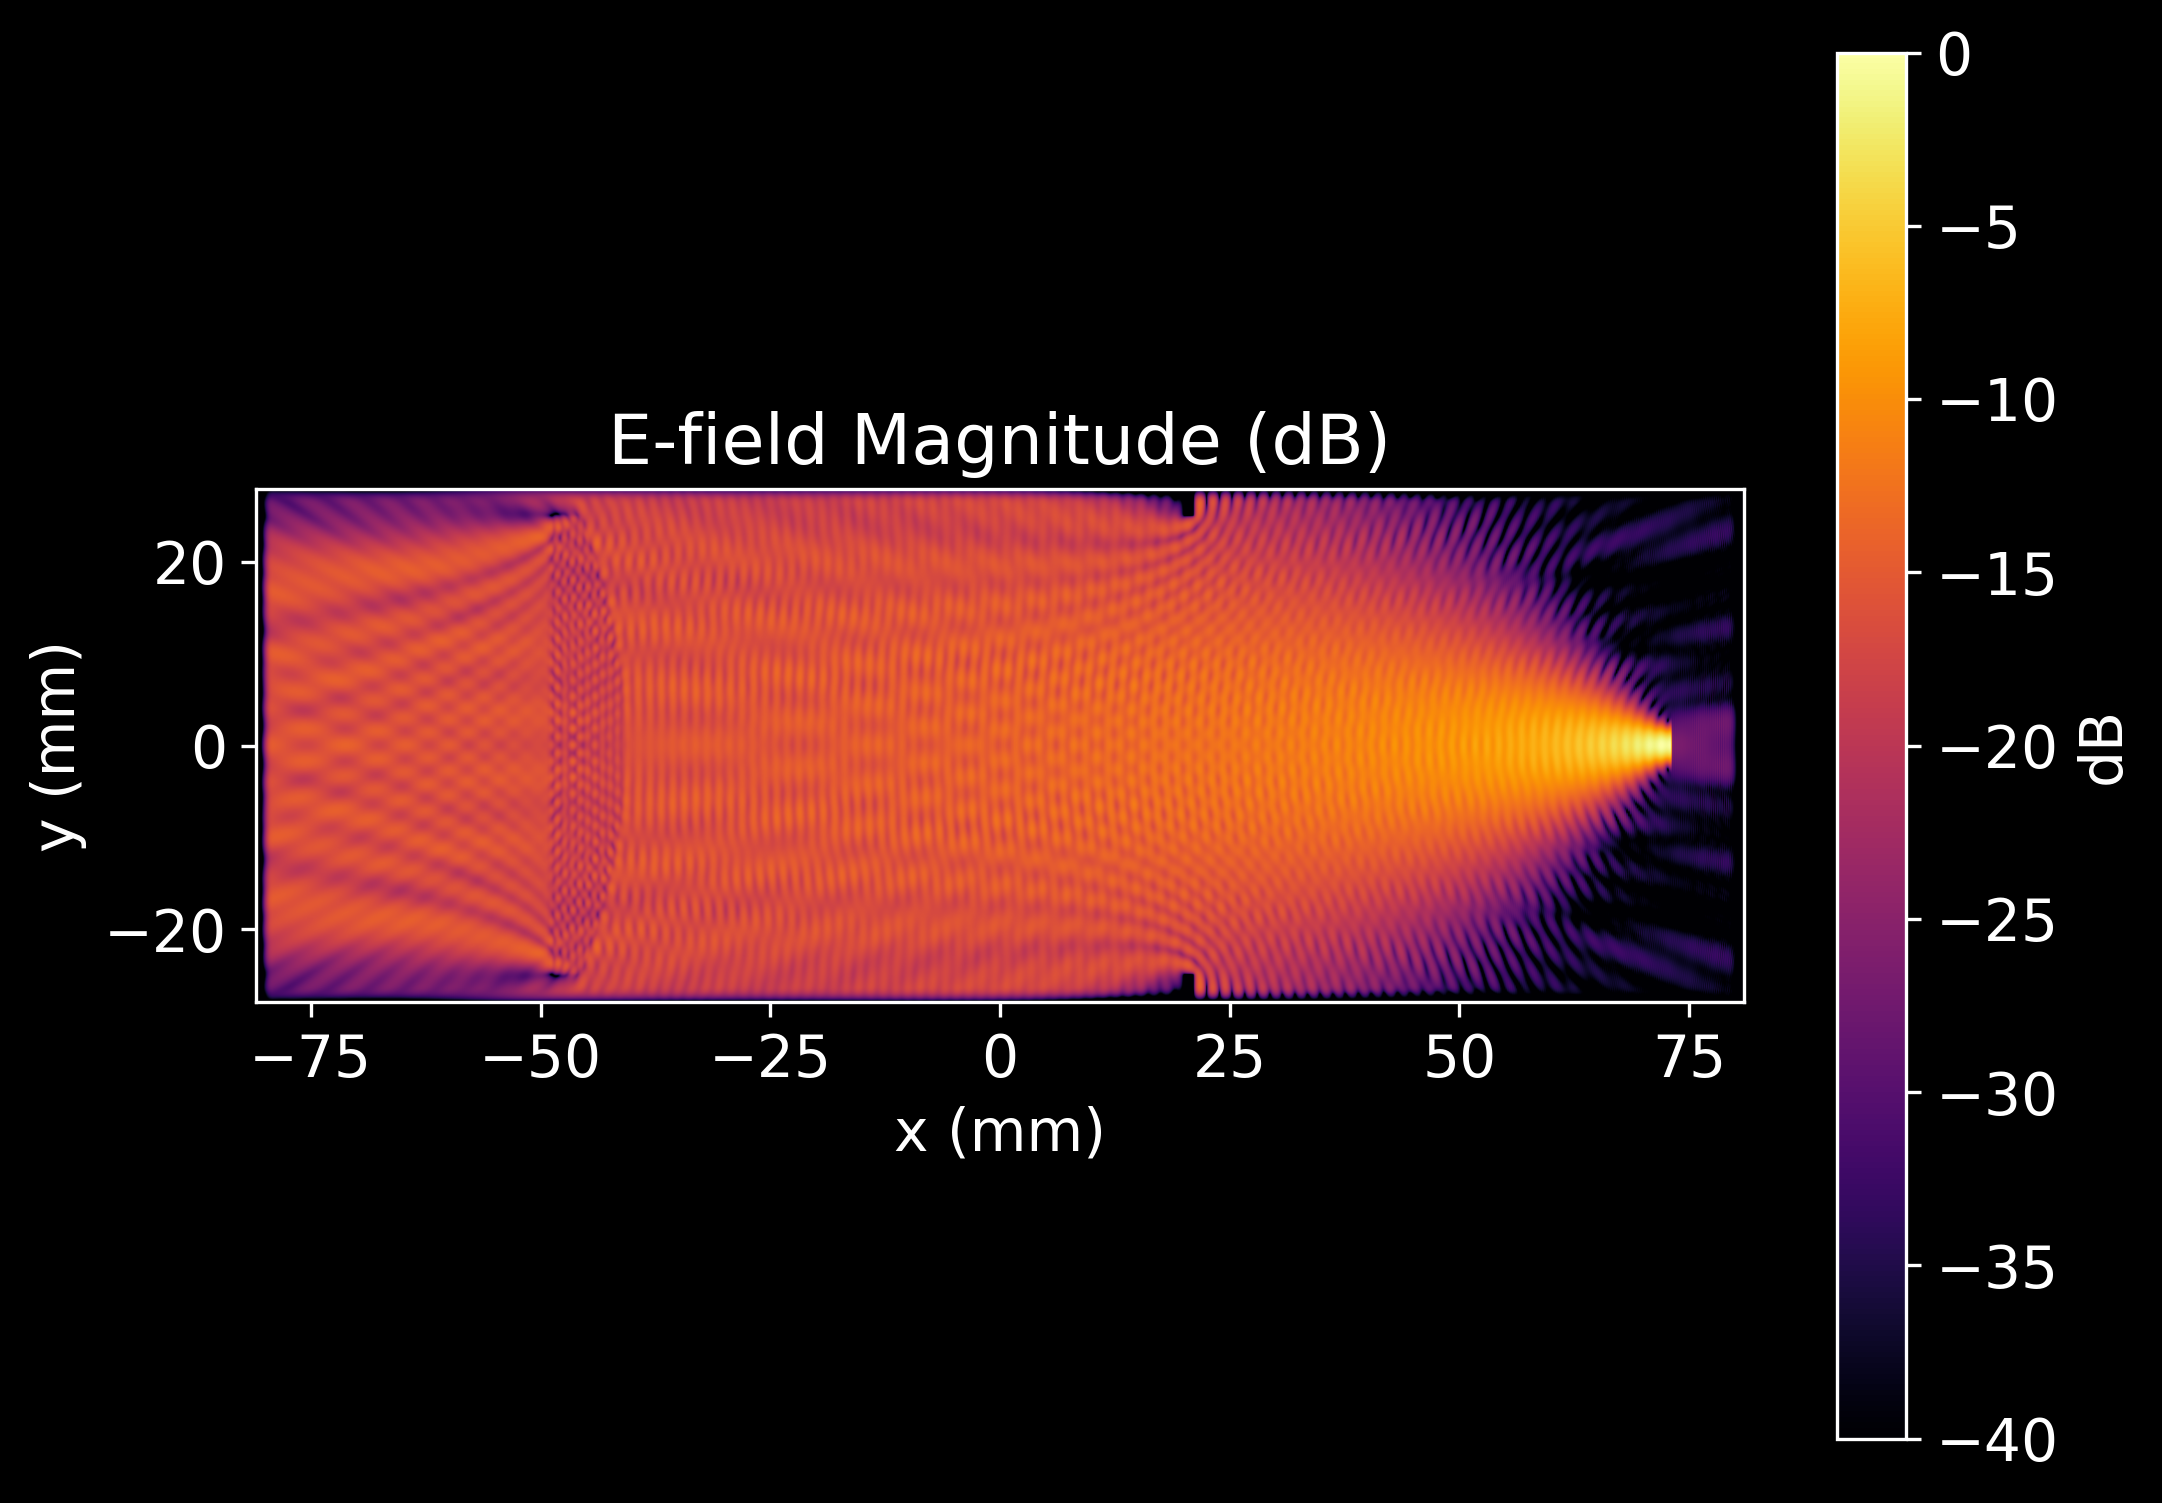

<Figure size 3600x3600 with 0 Axes>

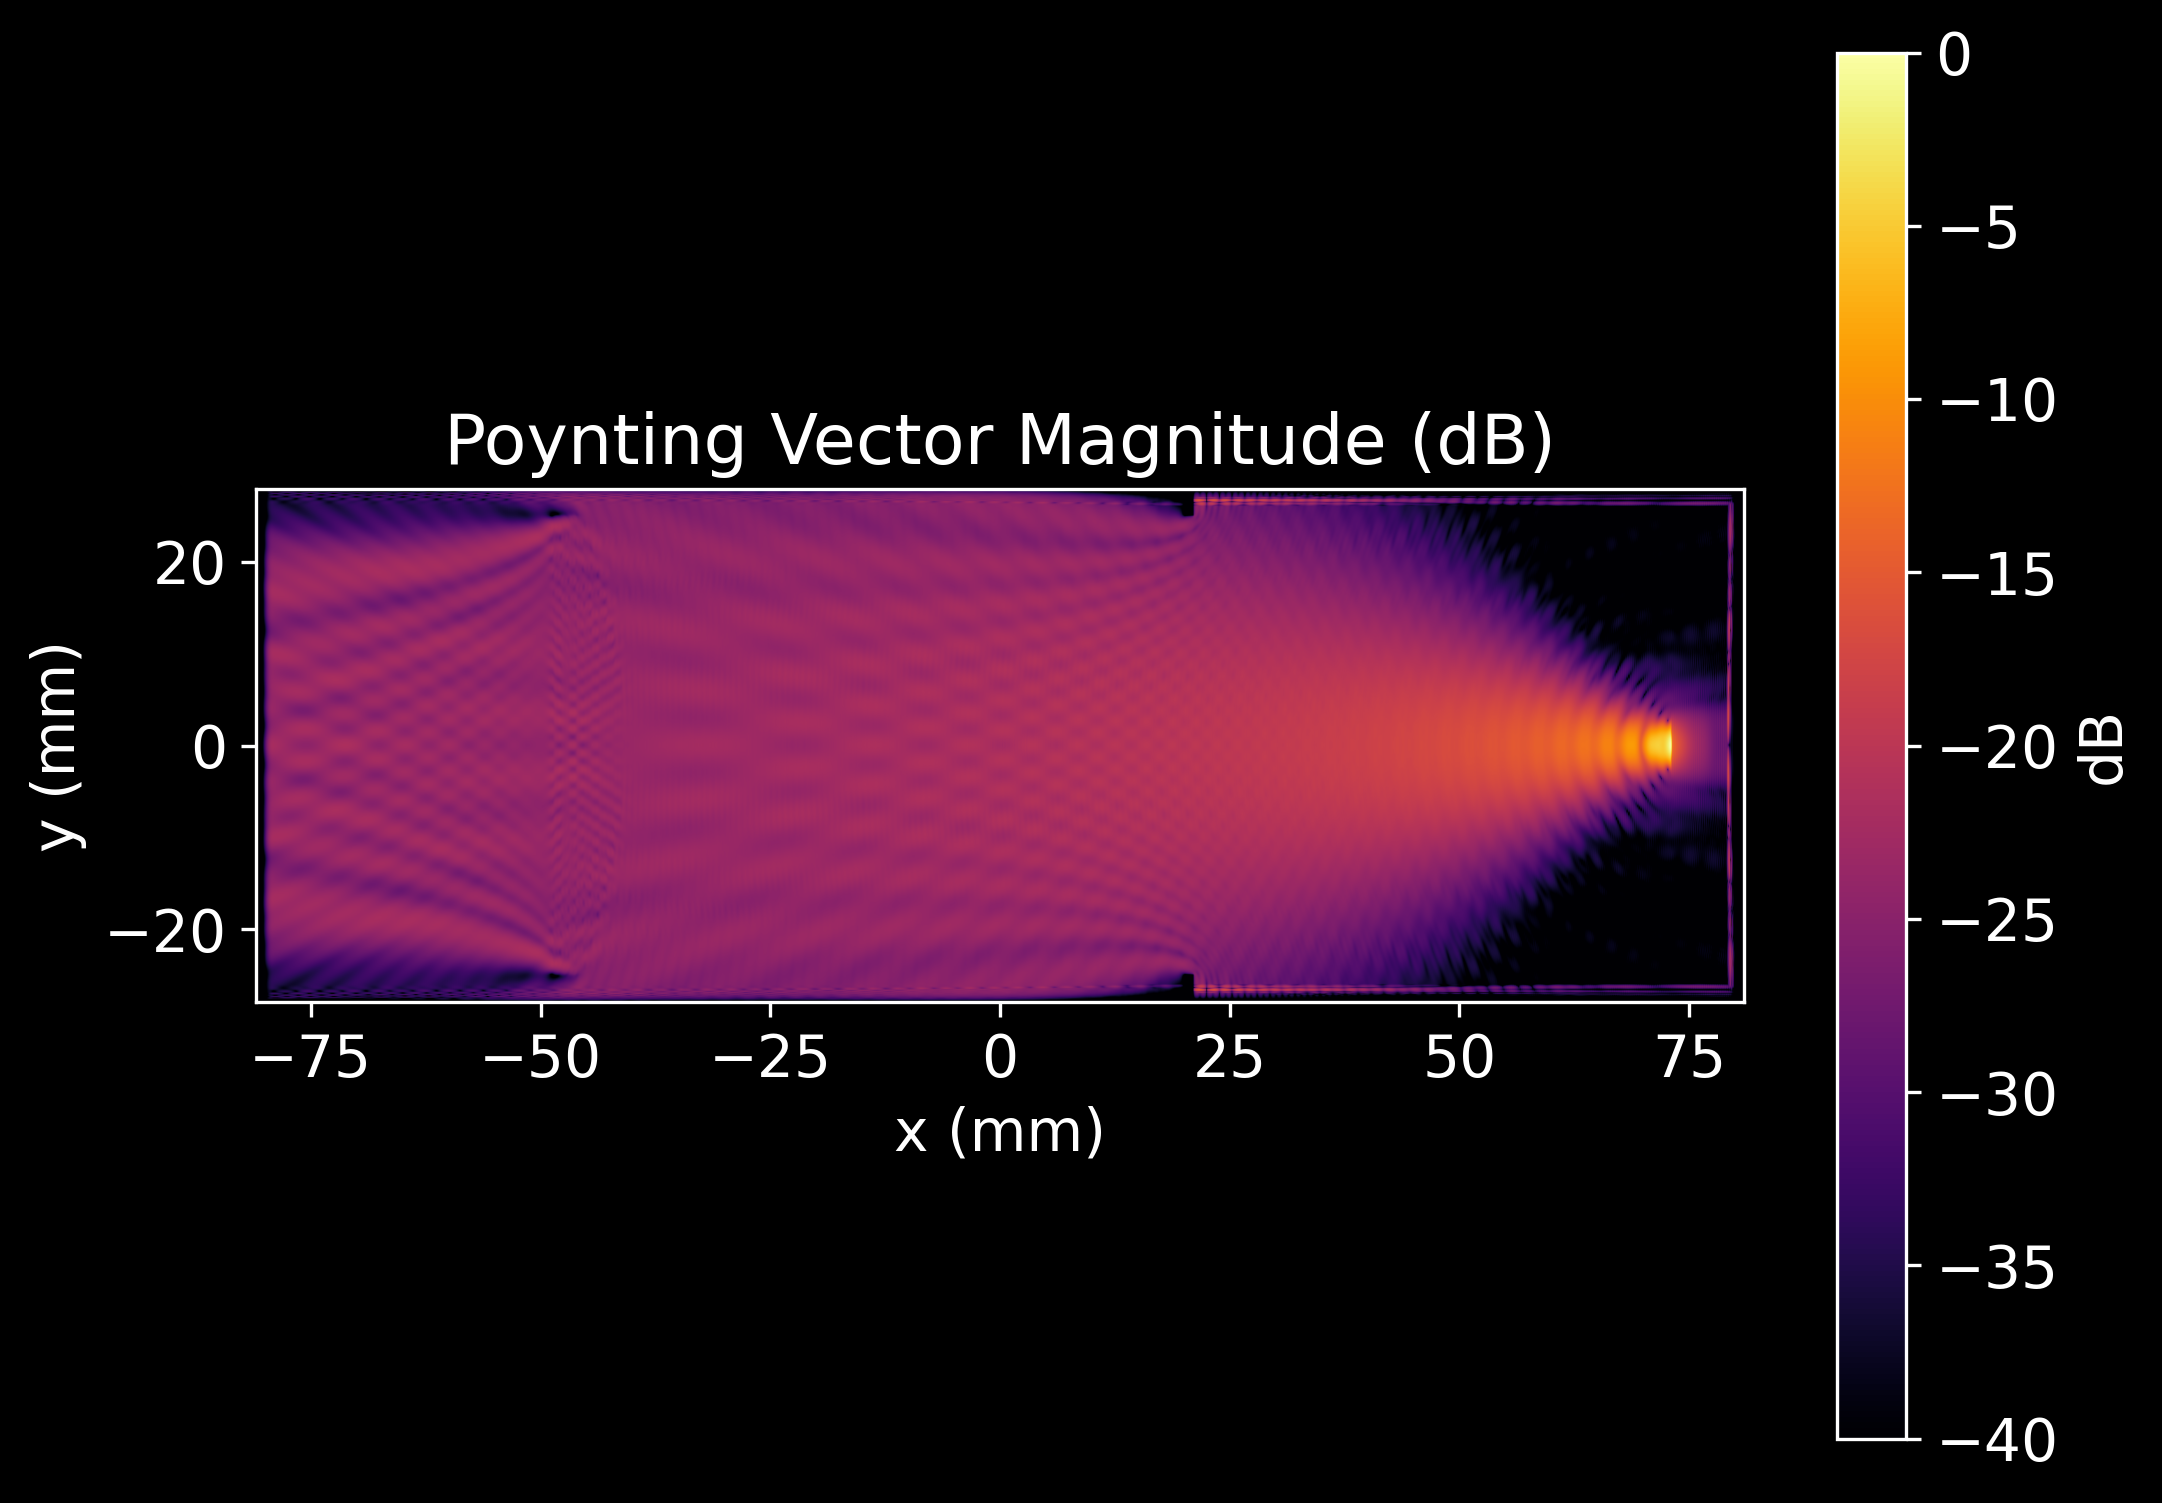

<Figure size 3600x3600 with 0 Axes>

In [16]:
def plot_field(simname, field_db, title, filename, xcoords, ycoords, vmin=-40, vmax=0, savepath= os.path.join('../../processed_data/'),
                show_plots=True):
    plt.figure(figsize=(8, 6))
    plt.imshow(field_db.T, extent=(xcoords[0], xcoords[-1], ycoords[0], ycoords[-1]),
               origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
    plt.colorbar(label='dB')
    plt.title(title)
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')

    if show_plots:
        plt.show()

    if savepath and not os.path.exists(os.path.join(savepath, simname)):
        os.makedirs(os.path.join(savepath, simname))
    plt.savefig(os.path.join(savepath, simname, filename), dpi=300)

# E-field plot
plot_field(simname = 'simple_single_lens_ARC', 
            field_db=ez_power_db, 
            title='E-field Magnitude (dB)', 
            filename='ez_magnitude_db.png', 
            xcoords=xyzw_data['x_coords'], 
            ycoords=xyzw_data['y_coords'])
# S-vector plot
plot_field(simname = 'simple_single_lens_ARC', 
            field_db= s_total_db, 
            title='Poynting Vector Magnitude (dB)', 
            filename='s_magnitude_db.png', 
            xcoords=xyzw_data['x_coords'], 
            ycoords=xyzw_data['y_coords'])

# Far Field Beam comparision with CST and GRASP!

In the current version of the MeepSAT, we extract the Far Field Beam profile using the [Fraunhofer diffraction](https://en.wikipedia.org/wiki/Fraunhofer_diffraction_equation) formula, where the far field is basically the fourier transform of the fields at the aperture. In the near future, we will also have the capabilties in MeepSAT to extract the far field beam using the spherical decomposition approach. 

First we will define the various dictionaries and file paths to the GRASP and CST simulations data followed by defining some customisable functions to read the aperture GRASP and CST simulated datasets. 

In [18]:
import meepsat.field_analysis as analysis

#FOR GRASP
def load_grasp_aperture_data(aperture_file, freq_label):
    print(f"Loading GRASP aperture data from: {aperture_file} for frequency label: {freq_label}")
    with h5py.File(aperture_file, 'r') as f:
        print("Keys in the HDF5 file:", list(f.keys()))
        print(f"Keys in the frequency group '{freq_label}':", list(f[freq_label].keys()))
        aperture_data = {
            'Ex': f[freq_label]['Ex'][:],
            'Ey': f[freq_label]['Ey'][:],
            'Ez': f[freq_label]['Ez'][:],
            'x': f[freq_label]['x'][:],
            'y': f[freq_label]['y'][:],
        }
        print("GRASP resolution (y)", analysis.calculate_grasp_resolution(aperture_data['y']))
    return aperture_data

def load_grasp_farfield_data(farfield_file, freq_label):
    print(f"Loading GRASP far field data from: {farfield_file} for frequency label: {freq_label}")
    with h5py.File(farfield_file, 'r') as f:
        print("Keys in the HDF5 file:", list(f.keys()))
        print(f"Keys in the frequency group '{freq_label}':", list(f[freq_label].keys()))
        Eco = f[freq_label]['Ex'][:]
        Ecx = f[freq_label]['Ey'][:]
        x = f[freq_label]['x'][:]
        
        Eco_dB = 10 * np.log10(np.abs(Eco)**2 / np.max(np.abs(Eco)**2))
        center_y, center_x = np.array(Eco_dB.shape) // 2
        
        return {
            'angle': x,
            'power_dB': Eco_dB[:, center_x],
        }

# FOR CST
def load_cst_data(ey_file, s_file, plot_label = 'CST TE'):
    # Load Ey data by using pandas
    import pandas as pd
    ey_data = pd.read_csv(ey_file, delim_whitespace=True, skiprows=3, names=['Y', 'Re(Ey)', 'Im(Ey)'])
    s_mag_data = pd.read_csv(s_file, delim_whitespace=True, skiprows=3, names=['Y', 'S_Mag_linear'])

    print(f"file found: {ey_file}, {s_file}")

    data_dict = {
        'efield': ey_data,
        's_mag': s_mag_data,
        'plot_label': plot_label
    }

    return data_dict

# ========================= GRASP aperture field data =============================
base_grasp_data_dir = Path('auxilary_data/simple_single_lens_ARC/GRASP_data/50mm_lens_sim')

"""
Define GRASP files in a structured way for extracting Aperture 
and farfield data (calculated within GRASP using spherical decomposition) 
for different simulation configurations (PO noARC, MoM with ARC, MoM noARC)
"""

grasp_files = {
    'PO_noARC': {
        'aperture': 'apertureField_PO.h5',
        'farfield': 'far_field_beams_PO.h5',
        'label': 'GRASP PO noARC'
    },
    'MoM_ARC': {
        'aperture': 'apertureField_MoM_AR.h5',
        'farfield': 'far_field_beams_MoM_AR.h5',
        'label': 'GRASP MoM with ARC'
    },
    'MoM_noARC': {
        'aperture': 'apertureField_MoM_noAR.h5',
        'farfield': 'far_field_beams_MoM_noAR.h5',
        'label': 'GRASP MoM noARC'
    }
}

# Add full paths
for key in grasp_files:
    grasp_files[key]['aperture'] = str(base_grasp_data_dir / f'50mm_lens_90120150GHz_{grasp_files[key]["aperture"]}')
    grasp_files[key]['farfield'] = str(base_grasp_data_dir / f'50mm_lens_90120150GHz_{grasp_files[key]["farfield"]}')
    

# Load all GRASP data
grasp_aperture_data = {}
grasp_farfield_data = {}
freq_to_analyse = '150'


for key, files in grasp_files.items():
    aperture_data = load_grasp_aperture_data(files['aperture'], freq_to_analyse)
    aperture_data['plot_label'] = files['label'].replace('GRASP ', '')
    grasp_aperture_data[key] = aperture_data
    
    farfield_data = load_grasp_farfield_data(files['farfield'], freq_to_analyse)
    farfield_data['plot_label'] = files['label']
    grasp_farfield_data[key] = farfield_data

# ========================= CST APERTURE DATA =============================
# TE Ey file format: 120mm_TE_Ey_ReIm_arc_{}_GHz.txt.format(freq)
# TM Ey file format: 120mm_TM_Ey_ReIm_arc_{}_GHz.txt.format(freq)
# TE S file format: 120mm_TE_S_Mag_arc_{}_GHz.txt.format(freq)
# TM S file format: 120mm_TM_S_Mag_arc_{}_GHz.txt.format(freq)

TE_Ey_data_file = Path('auxilary_data/simple_single_lens_ARC/CST_data/ARC/Field data along both X and Y slices 120mm focus (TM and TE pols)/120mm_TE_Ey_ReIm_arc_{}_GHz.txt'.format(freq_to_analyse))
TE_S_data_file = Path('auxilary_data/simple_single_lens_ARC/CST_data/ARC/Field data along both X and Y slices 120mm focus (TM and TE pols)/120mm_TE_S_Mag_arc_{}_GHz.txt'.format(freq_to_analyse))

CST_data_with_ARC = load_cst_data(TE_Ey_data_file, TE_S_data_file, plot_label='CST TE (with ARC)')


Loading GRASP aperture data from: auxilary_data/simple_single_lens_ARC/GRASP_data/50mm_lens_sim/50mm_lens_90120150GHz_apertureField_PO.h5 for frequency label: 150
Keys in the HDF5 file: ['120', '150', '90', 'Optical configuration']
Keys in the frequency group '150': ['Ex', 'Ey', 'Ez', 'x', 'y']
GRASP data has 101 points with spacing 0.6000000000000014 mm
GRASP resolution (y) 1.6666666666666627
Loading GRASP far field data from: auxilary_data/simple_single_lens_ARC/GRASP_data/50mm_lens_sim/50mm_lens_90120150GHz_far_field_beams_PO.h5 for frequency label: 150
Keys in the HDF5 file: ['120', '150', '90', 'Optical configuration']
Keys in the frequency group '150': ['Ex', 'Ey', 'x', 'y']
Loading GRASP aperture data from: auxilary_data/simple_single_lens_ARC/GRASP_data/50mm_lens_sim/50mm_lens_90120150GHz_apertureField_MoM_AR.h5 for frequency label: 150
Keys in the HDF5 file: ['120', '150', '90', 'Optical configuration']
Keys in the frequency group '150': ['Ex', 'Ey', 'Ez', 'x', 'y']
GRASP data

Now we will be calculating the far field beam from the aperture field profile from GRASP, CST and MeepSAT!

In [ ]:
# GRASP MOM FARFIELD
grasp_MOM_fft_dict = analysis.grasp_far_field_fft(grasp_data = grasp_aperture_data['MoM_ARC'],
                                                  wavelength= 1/data['sources']['source1']['frequecy'],
                                                  aper_size = data["apertures"]["aperture1"]["diameter"],  
                                                  zero_pad_beam=15, 
                                                  plot_label='GRASP MOM')

# GRASP PO FARFIELD
grasp_PO_fft_dict = analysis.grasp_far_field_fft(grasp_data = grasp_aperture_data['PO_noARC'],
                                                  wavelength= 1/data['sources']['source1']['frequecy'],
                                                  aper_size = data["apertures"]["aperture1"]["diameter"],  
                                                  zero_pad_beam=15, 
                                                  plot_label='GRASP PO')

# CST Farfield (using the S magnitude data)
                                                  

GRASP data has 101 points with spacing 0.6000000000000014 mm
GRASP Resolution: 1.6666666666666627 points per mm
Data filtered to aperture size of 50 mm. New data length: 83
GRASP data has 101 points with spacing 0.6000000000000014 mm
GRASP Resolution: 1.6666666666666627 points per mm
Data filtered to aperture size of 50 mm. New data length: 83


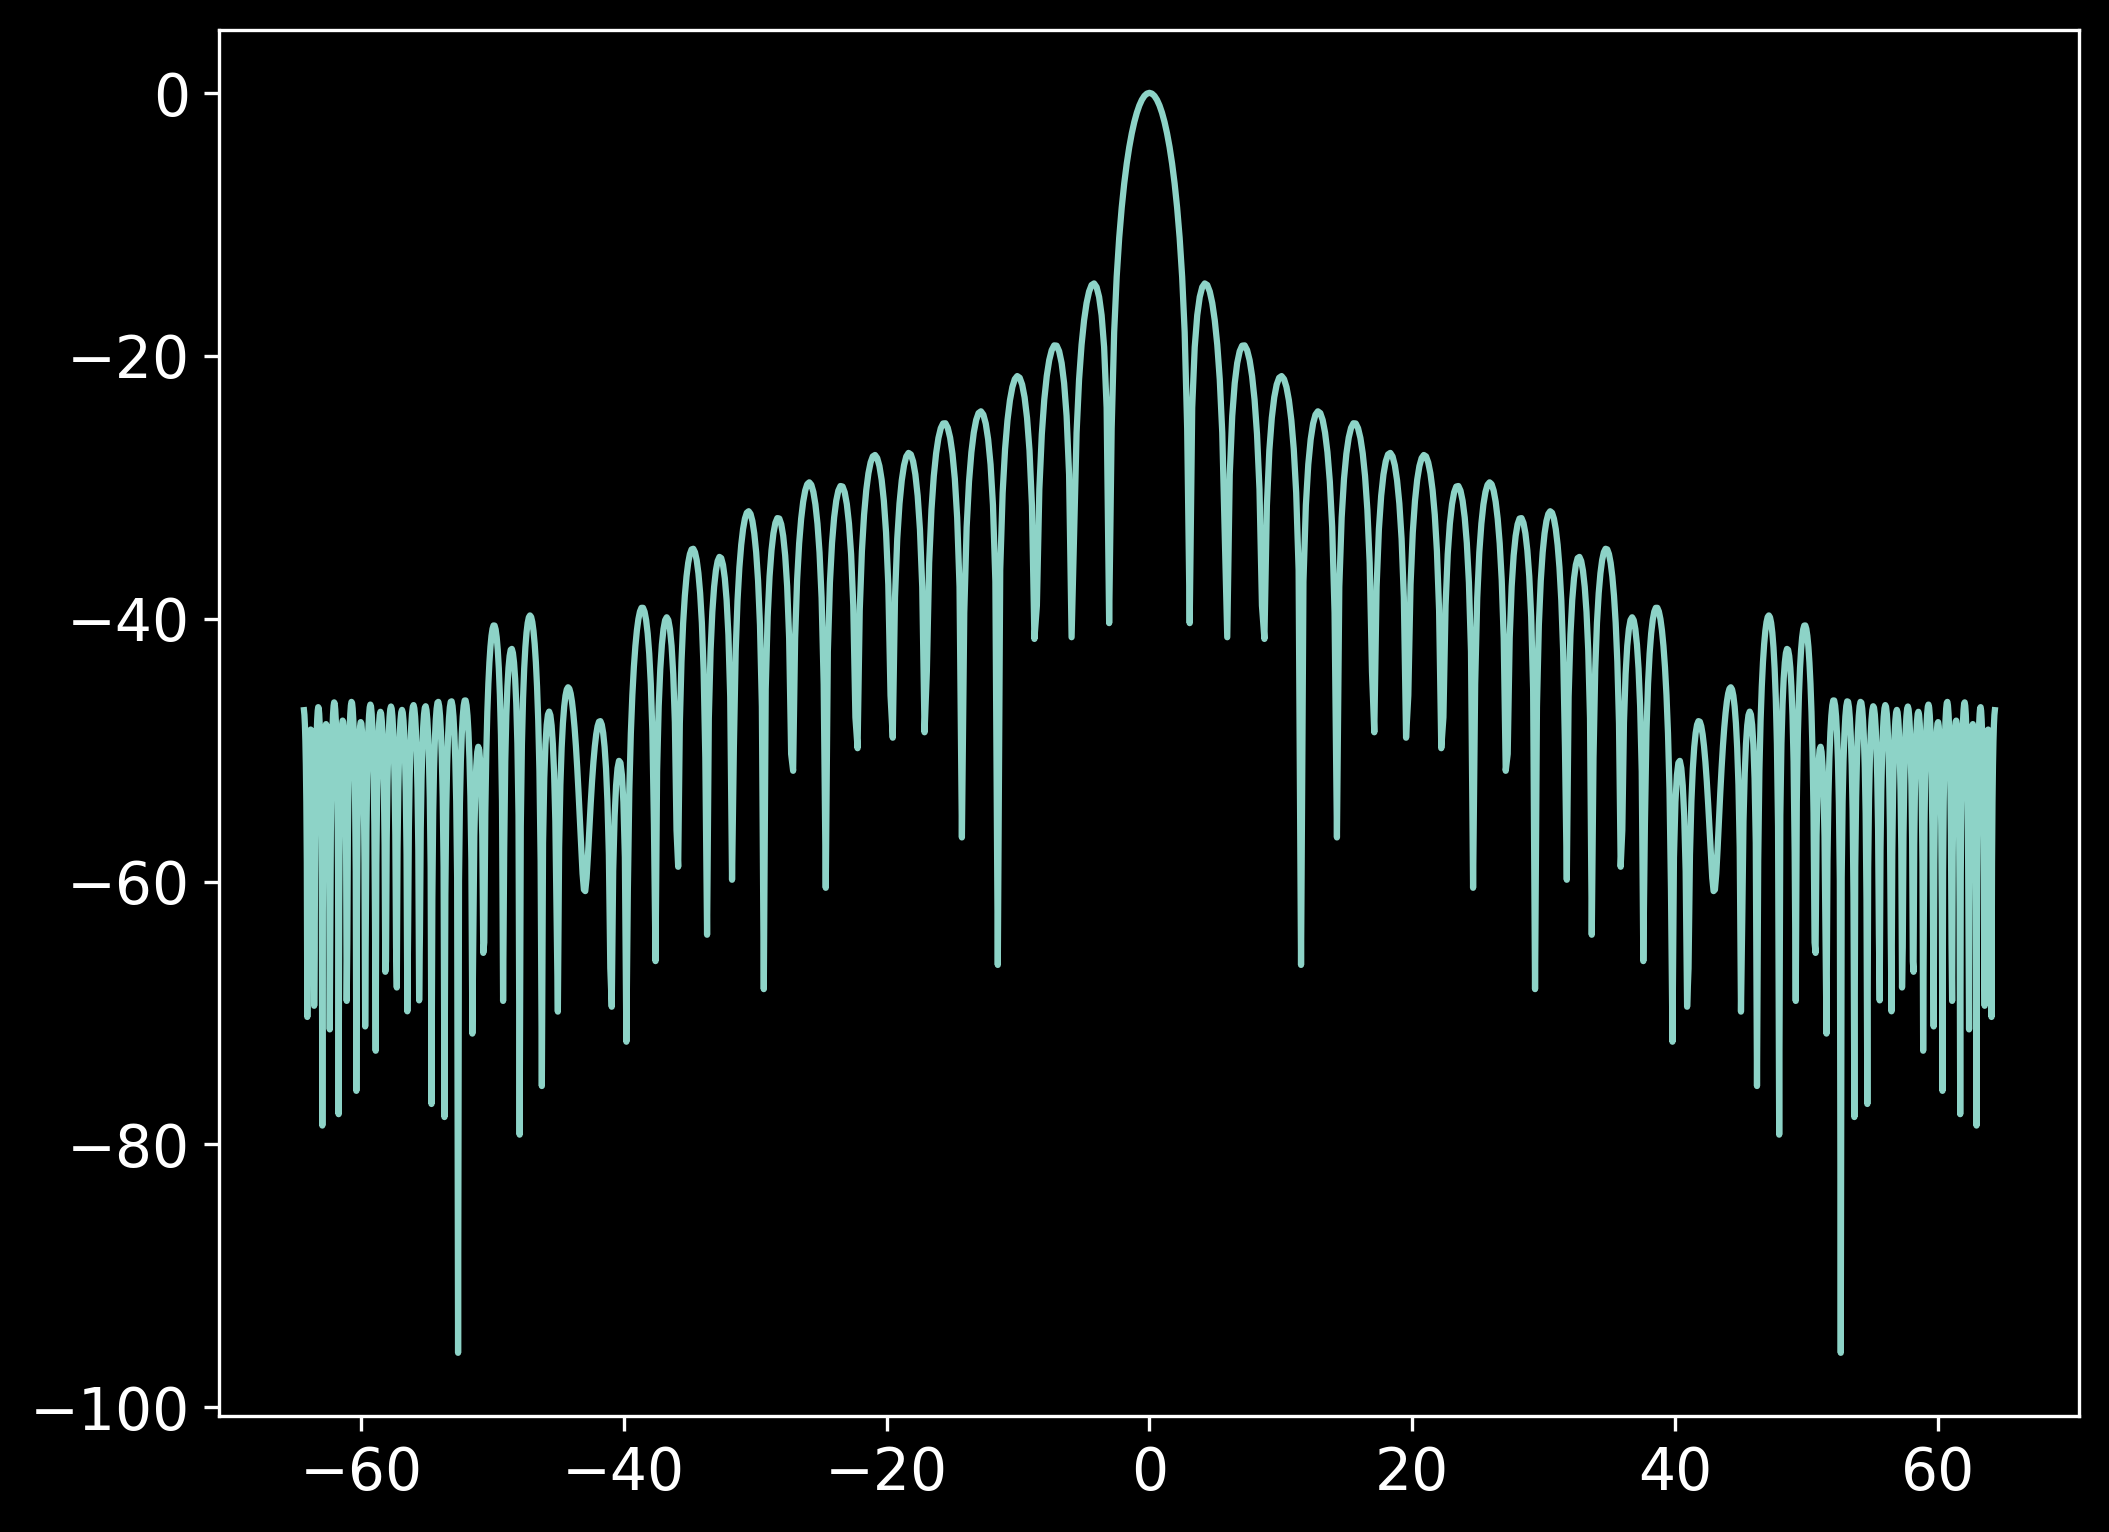

In [23]:
plt.figure(figsize=(8, 6))
plt.plot(grasp_PO_fft_dict['angle'], grasp_PO_fft_dict['power_dB'])#, label=grasp_MOM_fft_dict['plot_label'])
